In [1]:
from pathlib import Path
import json
import shutil

import numpy as np
from PIL import Image

In [2]:
PROJECT_DIR = Path.cwd().parent

DATASET_DIR = (
    PROJECT_DIR
    / "data"
    / "raw"
    / "Drone-Traffic.v1i.coco-segmentation"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "drone_traffic_yolo"
)

DETECTION_OUTPUT_DIR = (
    PROJECT_DIR / "data" / "processed" / "drone_traffic_detection"
)

print("Projeto:", PROJECT_DIR)
print("Dataset:", DATASET_DIR)
print("Saída:", OUTPUT_DIR)

Projeto: c:\Users\Andrezinho\OneDrive\Documentos\GitHub\AeroVision
Dataset: c:\Users\Andrezinho\OneDrive\Documentos\GitHub\AeroVision\data\raw\Drone-Traffic.v1i.coco-segmentation
Saída: c:\Users\Andrezinho\OneDrive\Documentos\GitHub\AeroVision\data\processed\drone_traffic_yolo


In [3]:
CLASS_MAPPING = {
    1: 0,  # bicycle
    2: 1,  # bus
    3: 2,  # car
    4: 3,  # lorry
}

CLASS_NAMES = [
    "bicycle",
    "bus",
    "car",
    "lorry",
]

print(CLASS_MAPPING)
print(CLASS_NAMES)

{1: 0, 2: 1, 3: 2, 4: 3}
['bicycle', 'bus', 'car', 'lorry']


In [4]:
for split in ["train", "val", "test"]:
    (OUTPUT_DIR / "images" / split).mkdir(
        parents=True,
        exist_ok=True
    )

    (OUTPUT_DIR / "labels" / split).mkdir(
        parents=True,
        exist_ok=True
    )

print("Estrutura criada em:")
print(OUTPUT_DIR)

Estrutura criada em:
c:\Users\Andrezinho\OneDrive\Documentos\GitHub\AeroVision\data\processed\drone_traffic_yolo


In [5]:
for split in ["train", "val", "test"]:
    (DETECTION_OUTPUT_DIR / "images" / split).mkdir(
        parents=True,
        exist_ok=True
    )

    (DETECTION_OUTPUT_DIR / "labels" / split).mkdir(
        parents=True,
        exist_ok=True
    )

print("Estrutura de detecção criada em:")
print(DETECTION_OUTPUT_DIR)

Estrutura de detecção criada em:
c:\Users\Andrezinho\OneDrive\Documentos\GitHub\AeroVision\data\processed\drone_traffic_detection


In [6]:
def convert_split(coco_split, output_split):
    annotation_file = (
        DATASET_DIR
        / coco_split
        / "_annotations.coco.json"
    )

    with open(annotation_file, "r", encoding="utf-8") as f:
        coco_data = json.load(f)

    images = {
        image["id"]: image
        for image in coco_data["images"]
    }

    annotations_by_image = {}

    for annotation in coco_data["annotations"]:
        image_id = annotation["image_id"]

        if image_id not in annotations_by_image:
            annotations_by_image[image_id] = []

        annotations_by_image[image_id].append(annotation)

    converted_images = 0
    converted_annotations = 0

    for image_id, image_info in images.items():

        width = image_info["width"]
        height = image_info["height"]
        file_name = image_info["file_name"]

        source_image = DATASET_DIR / coco_split / file_name

        destination_image = (
            OUTPUT_DIR
            / "images"
            / output_split
            / file_name
        )

        shutil.copy2(
            source_image,
            destination_image
        )

        label_file = (
            OUTPUT_DIR
            / "labels"
            / output_split
            / Path(file_name).with_suffix(".txt").name
        )

        lines = []

        for annotation in annotations_by_image.get(image_id, []):

            category_id = annotation["category_id"]

            if category_id not in CLASS_MAPPING:
                continue

            class_id = CLASS_MAPPING[category_id]

            segmentation = annotation["segmentation"]

            if not isinstance(segmentation, list):
                continue

            polygon = segmentation[0]

            if len(polygon) < 6:
                continue

            normalized_polygon = []

            for i in range(0, len(polygon), 2):

                px = polygon[i] / width
                py = polygon[i + 1] / height

                normalized_polygon.extend([px, py])

            # Formato YOLO-Seg:
            # class x1 y1 x2 y2 x3 y3 ...

            line = [class_id, *normalized_polygon]

            lines.append(
                " ".join(
                    f"{value:.6f}"
                    if isinstance(value, float)
                    else str(value)
                    for value in line
                )
            )

            converted_annotations += 1

        with open(
            label_file,
            "w",
            encoding="utf-8"
        ) as f:
            f.write("\n".join(lines))

        converted_images += 1

    print(
        f"{coco_split} → {output_split}: "
        f"{converted_images} imagens | "
        f"{converted_annotations} anotações"
    )

In [7]:
def convert_detection_split(coco_split, output_split):
    annotation_file = (
        DATASET_DIR / coco_split / "_annotations.coco.json"
    )

    with open(annotation_file, "r", encoding="utf-8") as f:
        coco_data = json.load(f)

    images = {
        image["id"]: image
        for image in coco_data["images"]
    }

    annotations_by_image = {}

    for annotation in coco_data["annotations"]:
        image_id = annotation["image_id"]

        if image_id not in annotations_by_image:
            annotations_by_image[image_id] = []

        annotations_by_image[image_id].append(annotation)

    converted_images = 0
    converted_annotations = 0

    for image_id, image_info in images.items():

        width = image_info["width"]
        height = image_info["height"]
        file_name = image_info["file_name"]

        source_image = DATASET_DIR / coco_split / file_name

        destination_image = (
            DETECTION_OUTPUT_DIR
            / "images"
            / output_split
            / file_name
        )

        shutil.copy2(
            source_image,
            destination_image
        )

        label_file = (
            DETECTION_OUTPUT_DIR
            / "labels"
            / output_split
            / Path(file_name).with_suffix(".txt").name
        )

        lines = []

        for annotation in annotations_by_image.get(image_id, []):

            category_id = annotation["category_id"]

            if category_id not in CLASS_MAPPING:
                continue

            class_id = CLASS_MAPPING[category_id]

            bbox = annotation.get("bbox")

            if bbox is None or len(bbox) != 4:
                continue

            x, y, bbox_width, bbox_height = bbox

            # Conversão COCO → YOLO
            center_x = (x + bbox_width / 2) / width
            center_y = (y + bbox_height / 2) / height

            normalized_width = bbox_width / width
            normalized_height = bbox_height / height

            line = (
                f"{class_id} "
                f"{center_x:.6f} "
                f"{center_y:.6f} "
                f"{normalized_width:.6f} "
                f"{normalized_height:.6f}"
            )

            lines.append(line)

            converted_annotations += 1

        with open(label_file, "w", encoding="utf-8") as f:
            f.write("\n".join(lines))

        converted_images += 1

    print(
        f"{coco_split} → {output_split}: "
        f"{converted_images} imagens | "
        f"{converted_annotations} anotações"
    )

In [8]:
convert_split("train", "train")
convert_split("valid", "val")
convert_split("test", "test")

train → train: 950 imagens | 14229 anotações
valid → val: 251 imagens | 3839 anotações
test → test: 118 imagens | 1697 anotações


In [9]:
convert_detection_split("train", "train")
convert_detection_split("valid", "val")
convert_detection_split("test", "test")

train → train: 950 imagens | 14229 anotações
valid → val: 251 imagens | 3839 anotações
test → test: 118 imagens | 1697 anotações


In [10]:
label_files = list(
    (DETECTION_OUTPUT_DIR / "labels" / "train").glob("*.txt")
)

sample_label = label_files[0]

print("Arquivo:")
print(sample_label)

with open(sample_label, "r", encoding="utf-8") as f:
    print(f.read()[:1000])

Arquivo:
c:\Users\Andrezinho\OneDrive\Documentos\GitHub\AeroVision\data\processed\drone_traffic_detection\labels\train\seq3-drone_0000002_jpg.rf.0d2d3558435d8ec2e4f2069e4819247d.txt
0 0.180889 0.293483 0.015625 0.038889
2 0.047556 0.995477 0.032612 0.010185
2 0.280469 0.595940 0.060937 0.086111
2 0.264924 0.184491 0.044271 0.056481
2 0.213141 0.144729 0.041667 0.049074
3 0.208614 0.181001 0.061458 0.087963
3 0.187841 0.212179 0.077604 0.116667
3 0.109435 0.146902 0.089062 0.111111
2 0.774559 0.522151 0.063542 0.073148


In [11]:
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle

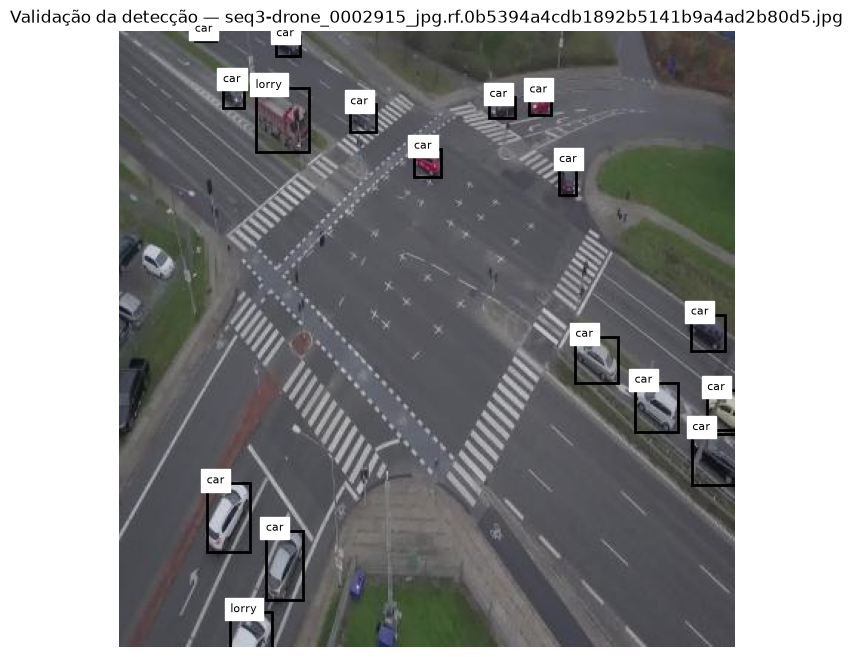

In [13]:
image_files = list(
    (DETECTION_OUTPUT_DIR / "images" / "train").glob("*.jpg")
)

image_path = random.choice(image_files)

label_path = (
    DETECTION_OUTPUT_DIR
    / "labels"
    / "train"
    / f"{image_path.stem}.txt"
)

image = Image.open(image_path).convert("RGB")

image_array = np.array(image)

height, width = image_array.shape[:2]

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(image_array)

with open(label_path, "r", encoding="utf-8") as f:

    for line in f:

        values = list(map(float, line.strip().split()))

        class_id = int(values[0])

        center_x = values[1] * width
        center_y = values[2] * height

        bbox_width = values[3] * width
        bbox_height = values[4] * height

        x = center_x - bbox_width / 2
        y = center_y - bbox_height / 2

        rectangle = Rectangle(
            (x, y),
            bbox_width,
            bbox_height,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rectangle)

        ax.text(
            x,
            y,
            CLASS_NAMES[class_id],
            fontsize=8,
            backgroundcolor="white"
        )

ax.set_title(
    f"Validação da detecção — {image_path.name}"
)

ax.axis("off")

plt.show()

In [14]:
# Escolher uma imagem aleatória do conjunto de treino

images_dir = OUTPUT_DIR / "images" / "train"
labels_dir = OUTPUT_DIR / "labels" / "train"

image_files = list(images_dir.glob("*.jpg"))

image_path = random.choice(image_files)
label_path = labels_dir / f"{image_path.stem}.txt"

print("Imagem:", image_path.name)
print("Labels:", label_path.name)

Imagem: seq3-drone_0001417_jpg.rf.1cd712e20fb2a81b0a0a098e23b61a06.jpg
Labels: seq3-drone_0001417_jpg.rf.1cd712e20fb2a81b0a0a098e23b61a06.txt


In [15]:
sample_label = next(
    (OUTPUT_DIR / "labels" / "train").glob("*.txt")
)

print("Arquivo:", sample_label.name)

with open(sample_label, "r", encoding="utf-8") as f:
    first_line = f.readline()

print(first_line)

Arquivo: seq3-drone_0000002_jpg.rf.0d2d3558435d8ec2e4f2069e4819247d.txt
0 0.186458 0.300926 0.185417 0.296296 0.184896 0.290741 0.184896 0.287037 0.183854 0.286111 0.182812 0.290741 0.181250 0.289815 0.180208 0.286111 0.179167 0.279630 0.177604 0.276852 0.176042 0.273148 0.173438 0.274074 0.172917 0.277778 0.172917 0.282407 0.174479 0.287963 0.175521 0.292593 0.176563 0.296296 0.176563 0.300926 0.177083 0.306481 0.178125 0.311111 0.179167 0.312037 0.179167 0.307407 0.179167 0.304630 0.180729 0.304630 0.181771 0.303704 0.183333 0.306481 0.184375 0.310185 0.185937 0.311111 0.187500 0.312037 0.188542 0.308333 0.187500 0.303704 0.186458 0.300926



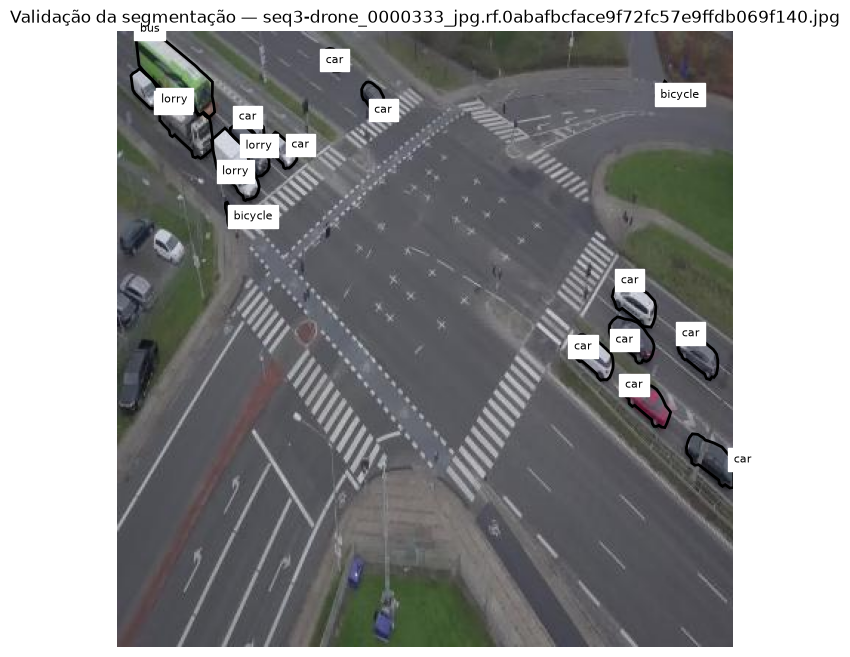

In [17]:
# Visualização das segmentações convertidas

image_files = list(
    (OUTPUT_DIR / "images" / "train").glob("*.jpg")
)

image_path = random.choice(image_files)

label_path = (
    OUTPUT_DIR
    / "labels"
    / "train"
    / f"{image_path.stem}.txt"
)

image = Image.open(image_path).convert("RGB")
image_array = np.array(image)

height, width = image_array.shape[:2]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image_array)

with open(label_path, "r", encoding="utf-8") as f:

    for line in f:

        values = list(
            map(float, line.strip().split())
        )

        class_id = int(values[0])

        polygon_values = values[1:]

        polygon_points = []

        for i in range(0, len(polygon_values), 2):

            x = polygon_values[i] * width
            y = polygon_values[i + 1] * height

            polygon_points.append((x, y))

        polygon = Polygon(
            polygon_points,
            closed=True,
            fill=False,
            linewidth=2
        )

        ax.add_patch(polygon)

        # posição do texto
        text_x, text_y = polygon_points[0]

        ax.text(
            text_x,
            text_y,
            CLASS_NAMES[class_id],
            fontsize=8,
            backgroundcolor="white"
        )

ax.set_title(
    f"Validação da segmentação — {image_path.name}"
)

ax.axis("off")
plt.show()